In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import os
from sklearn.pipeline import Pipeline

In [40]:
pth = os.path.abspath(os.path.join(os.getcwd(), ".."))
pth = os.path.abspath(os.path.join(pth, "data/augmented"))
print(pth)  # Affiche le répertoire parent

c:\Users\DF6610\Challenge_tech\data\augmented


In [41]:
df_train = pd.read_csv(pth + "/train.csv")
df_val = pd.read_csv(pth + "/val.csv")
df_test = pd.read_csv(pth + "/test.csv")

In [42]:
label_mapping={'out_of_scope': 0,
 'translate': 1,
 'book_flight': 2,
 'lost_luggage': 3,
 'travel_alert': 4,
 'travel_suggestion': 5,
 'carry_on': 6,
 'book_hotel': 7,
 'flight_status': 8}

In [43]:
X_train= df_train['text']
y_train = df_train['label'].map(label_mapping)

X_val = df_val['text']
y_val = df_val['label'].map(label_mapping)

X_test = df_test['text']
y_test = df_test['label'].map(label_mapping)



In [44]:
df_train_full = pd.concat([df_train, df_val], ignore_index=True)
X_train_full = df_train_full['text']
y_train_full = df_train_full['label'].map(label_mapping)

In [45]:
y_train_full.value_counts()

label
0    228
3    119
8     94
5     91
2     84
7     80
6     77
1     74
4     72
Name: count, dtype: int64

In [46]:

frequencies = dict(y_train_full.value_counts())
# Total des échantillons
total_samples = sum(frequencies.values())
# Calcul des poids inversés
weights = {key: total_samples / (freq * len(frequencies)) for key, freq in frequencies.items()}
# Appliquer un facteur de 2 à la classe 3 pour augmenter son poids
weights[3] *= 2
weights


{0: np.float64(0.44785575048732945),
 3: np.float64(1.7161531279178337),
 8: np.float64(1.08628841607565),
 5: np.float64(1.122100122100122),
 2: np.float64(1.2156084656084656),
 7: np.float64(1.2763888888888888),
 6: np.float64(1.326118326118326),
 1: np.float64(1.37987987987988),
 4: np.float64(1.4182098765432098)}

In [47]:
n = 5000 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

In [48]:
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes
class_weights = weights
svm_model = SVC(kernel='linear', random_state=42,class_weight=class_weights)
svm_model.fit(X_train_tfidf, y_train)


SVC(class_weight={0: np.float64(0.44785575048732945),
                  1: np.float64(1.37987987987988),
                  2: np.float64(1.2156084656084656),
                  3: np.float64(1.7161531279178337),
                  4: np.float64(1.4182098765432098),
                  5: np.float64(1.122100122100122),
                  6: np.float64(1.326118326118326),
                  7: np.float64(1.2763888888888888),
                  8: np.float64(1.08628841607565)},
    kernel='linear', random_state=42)

In [49]:
# Prédire sur l'ensemble de test
y_val_pred = svm_model.predict(X_val_tfidf)

# Afficher les résultats de classification
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.76      0.67      0.71        51
           1       0.25      0.14      0.18         7
           2       0.64      0.50      0.56        14
           3       0.53      0.90      0.67        21
           4       0.67      0.55      0.60        11
           5       0.27      0.14      0.19        21
           6       1.00      1.00      1.00        11
           7       0.71      1.00      0.83        20
           8       0.95      1.00      0.98        21

    accuracy                           0.69       177
   macro avg       0.64      0.66      0.63       177
weighted avg       0.67      0.69      0.67       177



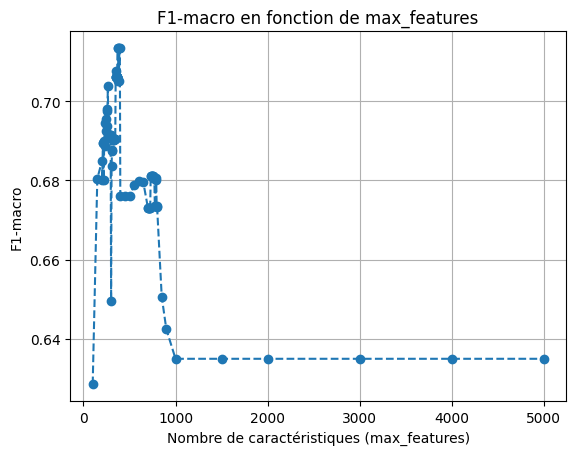

Meilleur nombre de caractéristiques (max_features) : 370
Meilleur F1-macro score : 0.7133623187672433


In [50]:


# Paramètres à tester avec GridSearch
param_grid = {
    
    'max_features': [100,150,200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355,356,357,358,359 ,360,361,362,363,364 ,365, 370, 375, 380, 385, 390, 395, 400,450,500,550,600,650,700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800,850,900,1000,1500,2000,3000,4000,5000]  # Différentes valeurs de n pour le TF-IDF
}


# Listes pour stocker les résultats
f1_scores = []
max_features_values = []

# Parcourir les différents paramètres de GridSearch
for max_feat in param_grid['max_features']:
    # Initialiser le vectoriseur TF-IDF avec un nombre de features (max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_feat)

    # Apprendre le vocabulaire et transformer les textes
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_val_tfidf = tfidf_vectorizer.transform(X_val)

    # Initialiser et entraîner le modèle SVM avec les poids de classe
    svm_model = SVC(kernel='linear', random_state=42, class_weight=class_weights)
    svm_model.fit(X_train_tfidf, y_train)

    # Prédictions sur l'ensemble de validation
    y_val_pred = svm_model.predict(X_val_tfidf)

    # Calculer la F1-macro score
    f1 = f1_score(y_val, y_val_pred, average='macro')
    
    # Ajouter les résultats à nos listes
    f1_scores.append(f1)
    max_features_values.append(max_feat)

# Tracer les F1-scores en fonction de max_features
plt.plot(max_features_values, f1_scores, marker='o', linestyle='--')
plt.xlabel('Nombre de caractéristiques (max_features)')
plt.ylabel('F1-macro')
plt.title('F1-macro en fonction de max_features')
plt.grid(True)
plt.show()

# Résultats finaux
best_max_features = max_features_values[f1_scores.index(max(f1_scores))]
print(f"Meilleur nombre de caractéristiques (max_features) : {best_max_features}")
print(f"Meilleur F1-macro score : {max(f1_scores)}")


In [51]:
# Next step 

# Entrainelent des modèles avec les meilleurs paramètres sur et train et val 
# faire une méthode d'ensemble

In [52]:
n = 370 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_full_tfidf = tfidf_vectorizer.fit_transform(X_train_full)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes


svm_model = SVC(kernel='linear', random_state=42,class_weight=class_weights)
svm_model.fit(X_train_full_tfidf, y_train_full)

# Prédire sur l'ensemble de test
y_test_pred = svm_model.predict(X_test_tfidf)

# Afficher les résultats de classification
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.55      0.94      0.70        51
           1       0.25      0.11      0.15         9
           2       0.86      0.90      0.88        21
           3       0.64      0.54      0.58        13
           4       0.67      0.67      0.67        18
           5       0.87      0.33      0.48        39
           6       1.00      0.85      0.92        39
           7       0.96      0.73      0.83        33
           8       0.61      0.85      0.71        20

    accuracy                           0.72       243
   macro avg       0.71      0.66      0.66       243
weighted avg       0.76      0.72      0.70       243



In [53]:
# Il y a bcp d'erreurs dans la classe 1, 3
# On modifie les poids

# Dictionnaire des poids de classes
weights[3] *= 8
weights[1] *= 8

class_weights=weights

In [54]:
n = 370 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_full_tfidf = tfidf_vectorizer.fit_transform(X_train_full)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes


svm_model = SVC(kernel='linear', random_state=42,class_weight=class_weights)
svm_model.fit(X_train_full_tfidf, y_train_full)

# Prédire sur l'ensemble de test
y_test_pred = svm_model.predict(X_test_tfidf)

# Afficher les résultats de classification
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.56      0.86      0.68        51
           1       0.53      0.89      0.67         9
           2       0.86      0.90      0.88        21
           3       0.64      0.54      0.58        13
           4       0.62      0.56      0.59        18
           5       0.87      0.33      0.48        39
           6       1.00      0.85      0.92        39
           7       1.00      0.73      0.84        33
           8       0.62      0.90      0.73        20

    accuracy                           0.72       243
   macro avg       0.75      0.73      0.71       243
weighted avg       0.78      0.72      0.72       243



In [57]:
n= 370
# Créer la pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=n)),  # Vectorisation TF-IDF
    ('svm', SVC(kernel='linear', random_state=42, class_weight=class_weights))  # Modèle SVM
])

# Entraîner la pipeline sur les données
pipeline.fit(X_train_full, y_train_full)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=370)),
                ('svm',
                 SVC(class_weight={0: np.float64(0.44785575048732945),
                                   1: np.float64(11.03903903903904),
                                   2: np.float64(1.2156084656084656),
                                   3: np.float64(13.72922502334267),
                                   4: np.float64(1.4182098765432098),
                                   5: np.float64(1.122100122100122),
                                   6: np.float64(1.326118326118326),
                                   7: np.float64(1.2763888888888888),
                                   8: np.float64(1.08628841607565)},
                     kernel='linear', random_state=42))])

In [58]:
# Prédire sur l'ensemble de test
y_test_pred = pipeline.predict(X_test)
# Afficher les résultats de classification
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.56      0.86      0.68        51
           1       0.53      0.89      0.67         9
           2       0.86      0.90      0.88        21
           3       0.64      0.54      0.58        13
           4       0.62      0.56      0.59        18
           5       0.87      0.33      0.48        39
           6       1.00      0.85      0.92        39
           7       1.00      0.73      0.84        33
           8       0.62      0.90      0.73        20

    accuracy                           0.72       243
   macro avg       0.75      0.73      0.71       243
weighted avg       0.78      0.72      0.72       243

